Week 3 Data cleaning

In [3]:
import pandas as pd
df_filtered = pd.read_csv('data_combined.csv')

In [4]:
import pandas as pd


missing_counts =df_filtered.isnull().sum()
missing_percent = (df_filtered .isnull().sum() / len(df_filtered)) * 100

missing_report = pd.DataFrame({
    'Missing_Count': missing_counts, 
    'Missing_Percent(%)': missing_percent
})


missing_report = missing_report[missing_report['Missing_Count'] > 0].sort_values(by='Missing_Percent(%)', ascending=False)

print(f"clean data: {len(df_filtered):,}")
print("missing report")

if missing_report.empty:
    print("no missing value")
else:
    print(missing_report.round(2))

clean data: 399,157
missing report
                       Missing_Count  Missing_Percent(%)
AssociationFee                122246               30.63
GarageSpaces                   14597                3.66
LotSizeSquareFeet               6826                1.71
YearBuilt                        308                0.08
LivingArea                       210                0.05
Latitude                         193                0.05
Longitude                        193                0.05
BathroomsTotalInteger             75                0.02
ClosePrice                         2                0.00
PostalCode                         2                0.00


Missing Value Analysis and Handling
1. High Missing Value Category (Missing > 30%): AssociationFee (Property/HOA Fees)

Business Insight: Missing values account for as much as 30.63% (nearly 120,000 records). In the real estate sector, this is definitely not due to agents forgetting to fill in the field, but rather “structural missing values”—meaning this single-family home simply does not have HOA fees!
Action Plan: Fill all missing values with 0.

2. Moderate Missing Data Tier (Missing 2%–5%): GarageSpaces (Number of Garage Spaces)

Business Insight: When entering data, agents often skip this field if there is no garage.
Remediation Strategy: Imputation with 0.

3. Extremely Low Missing Value Tier (Missing < 2%): Area, Year, Coordinates, Target Variable

Business Insight: For area data such as LotSizeSquareFeet (1.71%) and LivingArea (0.05%), or the ultimate target variable we aim to predict—ClosePrice (0.00%)—the missing values fall under the category of “Missing Completely at Random.”
Action Plan: For target variables and core area metrics, data must never be imputed (i.e., average values must not be used). Given that the missing values are extremely rare, the safest approach is to “directly delete these incomplete rows” (Listwise Deletion).


In [5]:
import pandas as pd

print(f"data size: {len(df_filtered):,}")

df_filtered['AssociationFee'] = df_filtered['AssociationFee'].fillna(0)
df_filtered['GarageSpaces'] =df_filtered['GarageSpaces'].fillna(0)


cols_to_drop_na = [
    'LotSizeSquareFeet', 'YearBuilt', 'LivingArea', 
    'Latitude', 'Longitude', 'BathroomsTotalInteger', 
    'ClosePrice', 'PostalCode'
]
df_filtered = df_filtered.dropna(subset=cols_to_drop_na)


print(f"size after dropping na: {len(df_filtered)}")



remaining_missing = df_filtered.isnull().sum().max()
if remaining_missing == 0:
    print("✅ dataset is clean！")
else:
    print(f"⚠️ rows with missing value: {remaining_missing}")

data size: 399,157
size after dropping na: 391590
✅ dataset is clean！


🚀 开始计算不同 K 值的误差，请稍等十几秒...
✅ 测试完成: K = 10
✅ 测试完成: K = 20
✅ 测试完成: K = 30
✅ 测试完成: K = 40
✅ 测试完成: K = 50
✅ 测试完成: K = 60
✅ 测试完成: K = 70
✅ 测试完成: K = 80
✅ 测试完成: K = 90
✅ 测试完成: K = 100


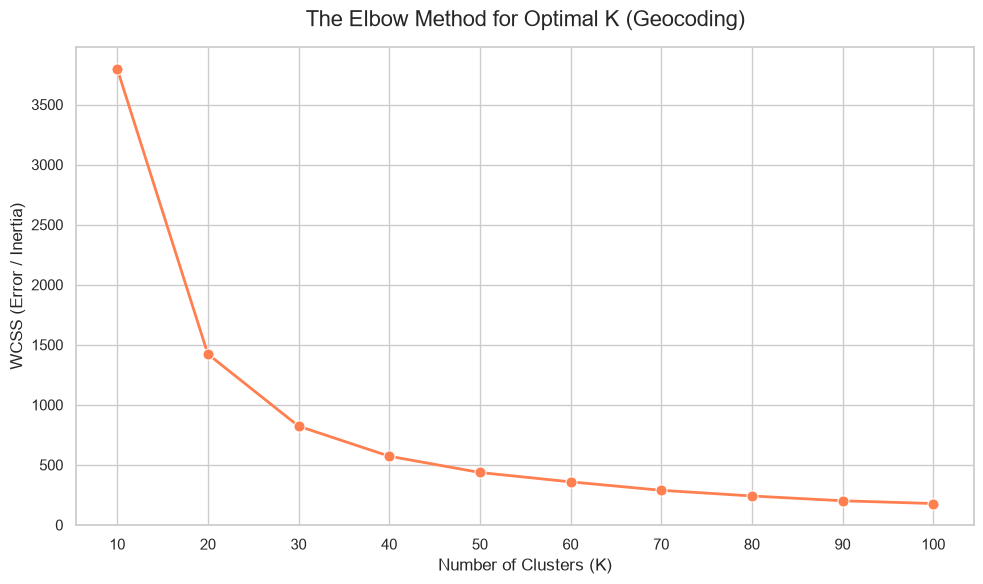

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


coords = df_filtered[['Latitude', 'Longitude']]


coords_sample = coords.sample(n=20000, random_state=42)


wcss = []


k_range = range(10, 101, 10)

print("🚀 开始计算不同 K 值的误差，请稍等十几秒...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(coords_sample)
    wcss.append(kmeans.inertia_)
    print(f"✅ 测试完成: K = {k}")


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(x=list(k_range), y=wcss, marker='o', markersize=8, linewidth=2, color='coral')

plt.title('The Elbow Method for Optimal K (Geocoding)', fontsize=16, pad=15)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Error / Inertia)')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

print(f"Clean data volume before applying the time filter: {len(df_filtered):,}")


df_filtered['CloseDate'] = pd.to_datetime(df_filtered['CloseDate'], errors='coerce')


cutoff_date = pd.to_datetime('2023-06-01')


df_recent = df_filtered[df_filtered['CloseDate'] >= cutoff_date].copy()


print("========= Time Truncation Report =========")

print(f"✅ Successfully retained core data from {cutoff_date.strftime('%Y-%m-%d')} onward!")
print(f"Final number of records retained: {len(df_recent):,}")
print(f"A total of {len(df_filtered) - len(df_recent):,} historical records from the older period were removed.")


Clean data volume before applying the time filter: 391,590
========= Time Truncation Report =========
✅ Successfully retained core data from 2023-06-01 onward!
Final number of records retained: 384,301
A total of 7,289 historical records from the older period were removed.


In [10]:
from sklearn.cluster import KMeans
import pandas as pd


final_coords = df_recent[['Latitude', 'Longitude']]
kmeans_final = KMeans(n_clusters=50, random_state=42, n_init='auto')


df_recent['Geo_Cluster'] = kmeans_final.fit_predict(final_coords)
df_recent['Geo_Cluster'] = 'cluster_' + df_recent['Geo_Cluster'].astype(str)


df_geo_encoded = pd.get_dummies(df_recent['Geo_Cluster'], drop_first=True, dtype=int)


df_final_modeling = pd.concat([df_recent, df_geo_encoded], axis=1)

print(f"\nnumber of features: {df_final_modeling.shape[1]} ")


number of features: 64 


We discarded the postal code, latitude, and longitude and replaced them with 50 business districts, effectively increasing the amount of information.

In [11]:
import pandas as pd


# 1. Identify the “useless category features” and “obsolete geographic features” we want to drop
cols_to_drop = [
    'PropertyType',       # All Residential; no variance
    'PropertySubType',    # All SingleFamilyResidence; no variance
    'PostalCode',         # Replaced by Geo_Cluster; would cause dimensionality catastrophe
    'Latitude',           # Replaced by Geo_Cluster
    'Longitude',          # Replaced by Geo_Cluster
    'Geo_Cluster'         # The original text label column; since we just ran `get_dummies` on it, we no longer need the original column
]


df_model_ready = df_final_modeling.drop(columns=cols_to_drop, errors='ignore')

print(f"Redundant category features have been cleaned up！")
print(f" The ideal data dimensions to feed into the model: {df_model_ready.shape}")

print(df_model_ready.dtypes.value_counts())

Redundant category features have been cleaned up！
 The ideal data dimensions to feed into the model: (384301, 58)
int64             49
float64            8
datetime64[us]     1
Name: count, dtype: int64


In [12]:

df_model_ready.to_csv('Cleaned_California_Housing.csv', index=False)


In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

def prepare_oot_modeling_data(df, target_col, x_months):

    df['CloseDate'] = pd.to_datetime(df['CloseDate'])

    max_date = df['CloseDate'].max()
    

    test_start_date = max_date - pd.DateOffset(months=1)

    train_start_date = test_start_date - pd.DateOffset(months=x_months)

    test_mask = (df['CloseDate'] > test_start_date) & (df['CloseDate'] <= max_date)
    train_mask = (df['CloseDate'] > train_start_date) & (df['CloseDate'] <= test_start_date)
    
    df_train = df[train_mask].copy()
    df_test = df[test_mask].copy()
    
        

    y_train = np.log1p(df_train[target_col]) 
    y_test = np.log1p(df_test[target_col])
    
    X_train = df_train.drop(columns=[target_col, 'CloseDate'])
    X_test = df_test.drop(columns=[target_col, 'CloseDate'])

    num_cols = ['LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 
                'BathroomsTotalInteger', 'YearBuilt', 'AssociationFee', 'GarageSpaces']
    
    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])
    
   
    print(f"🚀 [Experiment] Training Window (X) = {x_months} Months")
    print(f"   ▶ Test Set (Fixed 1 Month) : {test_start_date.date()} to {max_date.date()} | Data Size: {len(df_test):,}")
    print(f"   ▶ Train Set (Past {x_months} Months): {train_start_date.date()} to {test_start_date.date()} | Data Size: {len(df_train):,}")
    return X_train, X_test, y_train, y_test



In [20]:
window_options = [3, 6, 9, 12]


datasets_dict = {}


for x in window_options:
    X_train, X_test, y_train, y_test = prepare_oot_modeling_data(
        df=df_model_ready, 
        target_col='ClosePrice', 
        x_months=x
    )
    
    if X_train is not None:
        datasets_dict[f"{x}_months"] = {
            'X_train': X_train, 'X_test': X_test, 
            'y_train': y_train, 'y_test': y_test
        }
    print("-" * 50)

🚀 [Experiment] Training Window (X) = 3 Months
   ▶ Test Set (Fixed 1 Month) : 2026-04-30 to 2026-05-31 | Data Size: 11,804
   ▶ Train Set (Past 3 Months): 2026-01-30 to 2026-04-30 | Data Size: 31,160
--------------------------------------------------
🚀 [Experiment] Training Window (X) = 6 Months
   ▶ Test Set (Fixed 1 Month) : 2026-04-30 to 2026-05-31 | Data Size: 11,804
   ▶ Train Set (Past 6 Months): 2025-10-30 to 2026-04-30 | Data Size: 58,756
--------------------------------------------------
🚀 [Experiment] Training Window (X) = 9 Months
   ▶ Test Set (Fixed 1 Month) : 2026-04-30 to 2026-05-31 | Data Size: 11,804
   ▶ Train Set (Past 9 Months): 2025-07-30 to 2026-04-30 | Data Size: 93,051
--------------------------------------------------
🚀 [Experiment] Training Window (X) = 12 Months
   ▶ Test Set (Fixed 1 Month) : 2026-04-30 to 2026-05-31 | Data Size: 11,804
   ▶ Train Set (Past 12 Months): 2025-04-30 to 2026-04-30 | Data Size: 127,566
--------------------------------------------